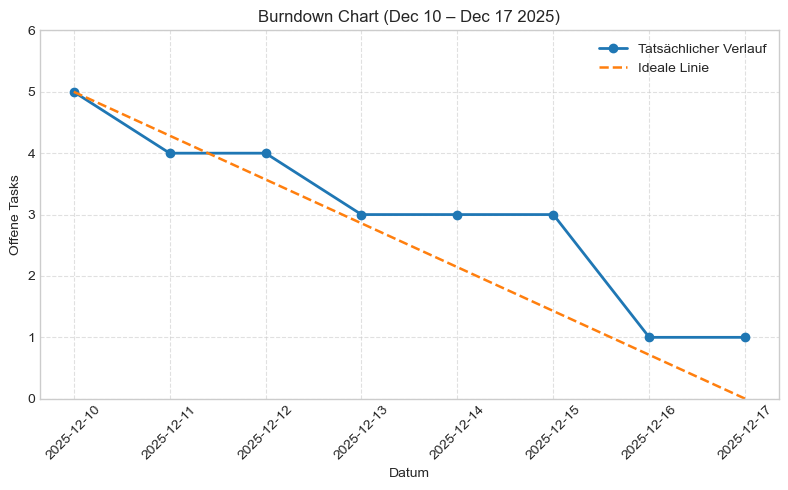

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Zeitspanne auswählen
dates = pd.date_range("2025-12-10", "2025-12-17")

# ✅ Hier manuell deine Task-Verläufe eintragen
remaining_tasks = [5, 4, 4, 3, 3, 3, 1, 1]

# Anzahl Gesamt-Tasks aus erstem Wert ableiten
tasks_total = remaining_tasks[0]

# DataFrame
data = pd.DataFrame({
    "Date": dates,
    "Remaining Tasks": remaining_tasks
})

plt.figure(figsize=(8, 5))
plt.plot(data["Date"], data["Remaining Tasks"], marker="o", linewidth=2, label="Tatsächlicher Verlauf")

plt.title("Burndown Chart (Dec 10 – Dec 17 2025)")
plt.xlabel("Datum")
plt.ylabel("Offene Tasks")

# ✅ Y-Achse mit extra Höhe
plt.yticks(range(0, tasks_total + 2))
plt.ylim(0, tasks_total + 1)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)

# ✅ Ideale Burndown-Linie (automatisch berechnet)
ideal_line = [tasks_total - (tasks_total / (len(dates)-1)) * i for i in range(len(dates))]
plt.plot(data["Date"], ideal_line, linestyle="--", linewidth=1.8, label="Ideale Linie")

plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Moritz\AppData\Local\Temp\ipykernel_19440\2913293529.py:70: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour_lines = pd.date_range(start=start_date, end=end_date, freq="6H")


Text(1.02, 0.04282986111111131, 'Gesamtstunden (Projekt): 280.1 h')

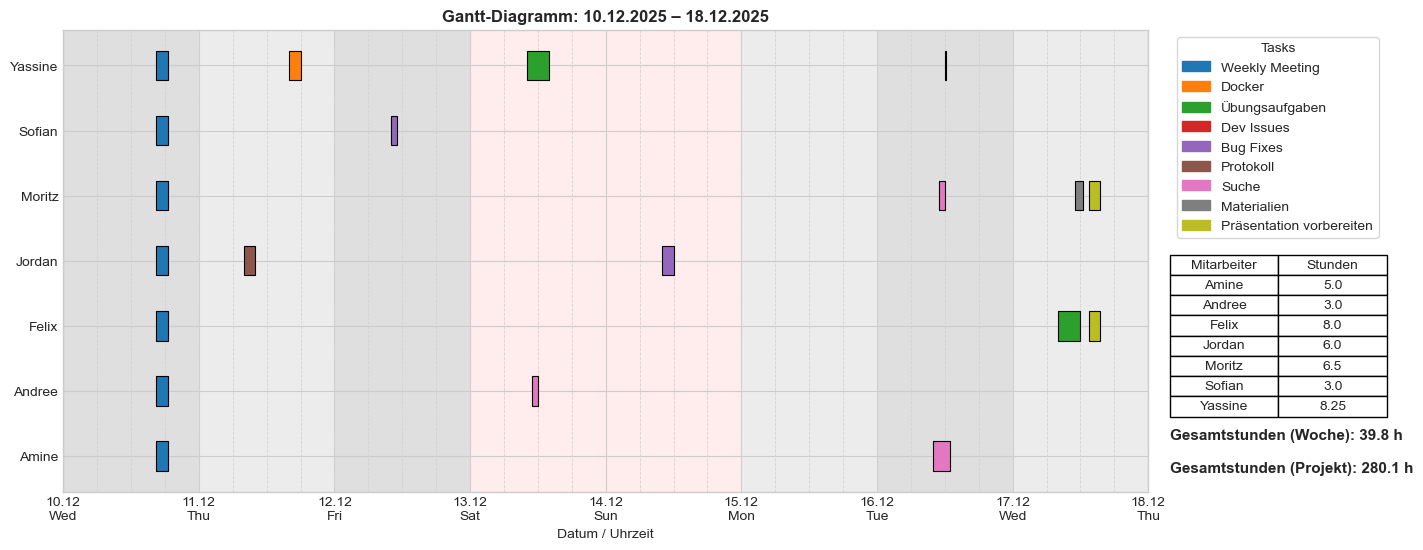

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from datetime import datetime, timedelta

# --- Datengrundlage ---
assignments = [
    ("Amine", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Andree", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Felix", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Moritz", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Sofian", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Yassine", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Jordan", "Weekly Meeting", "2025-12-10 16:30", "2025-12-10 18:30"),
    ("Yassine", "Docker", "2025-12-11 16:00", "2025-12-11 18:00"),
    ("Yassine", "Übungsaufgaben", "2025-12-13 10:00", "2025-12-13 14:00"),
    ("Yassine", "Dev Issues", "2025-12-16 12:00", "2025-12-16 12:15"),
    ("Sofian", "Bug Fixes", "2025-12-12 10:00", "2025-12-12 11:00"),
    ("Jordan", "Bug Fixes", "2025-12-14 10:00", "2025-12-14 12:00"),
    ("Jordan", "Protokoll", "2025-12-11 08:00", "2025-12-11 10:00"),
    ("Andree", "Suche", "2025-12-13 11:00", "2025-12-13 12:00"),

    ("Amine", "Suche", "2025-12-16 10:00", "2025-12-16 13:00"),
    ("Moritz", "Suche", "2025-12-16 11:00", "2025-12-16 12:00"),
    ("Moritz", "Materialien", "2025-12-17 11:00", "2025-12-17 12:30"),
    ("Felix", "Übungsaufgaben", "2025-12-17 08:00", "2025-12-17 12:00"),
    ("Felix", "Präsentation vorbereiten", "2025-12-17 13:30", "2025-12-17 15:30"),
    ("Moritz", "Präsentation vorbereiten", "2025-12-17 13:30", "2025-12-17 15:30"),
    ]

df = pd.DataFrame(assignments, columns=["employee", "task", "start", "end"])
df["start"] = pd.to_datetime(df["start"])
df["end"] = pd.to_datetime(df["end"])

# --- Mitarbeiter chronologisch sortieren ---
first_tasks = df.groupby("employee")["start"].min().sort_values()
employees = first_tasks.index.tolist()
y_pos = {emp: i for i, emp in enumerate(employees)}

# --- Farben pro Task ---
colors = list(mcolors.TABLEAU_COLORS.values())
task_colors = {task: colors[i % len(colors)] for i, task in enumerate(df["task"].unique())}

# --- Plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# --- Hintergrund einfärben: ganze Tage ---
start_date = df["start"].dt.floor("D").min()
end_date = df["end"].dt.ceil("D").max()

curr_date = start_date
while curr_date < end_date:
    next_day = curr_date + timedelta(days=1)
    day_start = datetime.combine(curr_date, datetime.min.time())
    day_end = datetime.combine(next_day, datetime.min.time())

    if curr_date.weekday() >= 5:
        color = "#ffeaea"  # Wochenende
    else:
        color = "#dcdcdc" if curr_date.day % 2 == 0 else "#eaeaea"

    ax.axvspan(mdates.date2num(day_start), mdates.date2num(day_end),
               facecolor=color, alpha=0.9, zorder=0)
    curr_date = next_day

# --- Vertikale Linien jede 6 Stunden ---
hour_lines = pd.date_range(start=start_date, end=end_date, freq="6H")
for h in hour_lines:
    ax.axvline(mdates.date2num(h), color="lightgray", linestyle="--", linewidth=0.6, zorder=1)

# --- Gantt-Balken ---
for _, r in df.iterrows():
    start_num = mdates.date2num(r["start"])
    end_num = mdates.date2num(r["end"])
    width = end_num - start_num
    y = y_pos[r["employee"]]

    ax.barh(y, width, left=start_num, height=0.45,
            color=task_colors[r["task"]], edgecolor="black", linewidth=0.8, zorder=2)

# --- Achsen & Formatierung ---
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(list(y_pos.keys()), fontsize=10)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m\n%a'))
ax.set_xlabel("Datum / Uhrzeit", fontsize=10)

ax.set_xlim([
    mdates.date2num(datetime.combine(start_date, datetime.min.time())),
    mdates.date2num(datetime.combine(end_date, datetime.min.time()))
])

ax.set_title(f"Gantt-Diagramm: {start_date:%d.%m.%Y} – {end_date:%d.%m.%Y}",
             fontsize=12, weight="bold")

# --- Legende ---
patches = [mpatches.Patch(color=c, label=t) for t, c in task_colors.items()]
legend = ax.legend(handles=patches, title="Tasks", loc='upper left',
                   bbox_to_anchor=(1.02, 1), frameon=True)

# ==========================
#  ARBEITSSTUNDEN-BERECHNUNG
# ==========================

df["hours"] = (df["end"] - df["start"]).dt.total_seconds() / 3600

# Gemeinsame Stunden werden allen Mitarbeitenden angerechnet
individual_hours = df.groupby("employee")["hours"].sum().reset_index()
individual_hours.columns = ["Mitarbeiter", "Stunden"]
individual_hours["Stunden"] = individual_hours["Stunden"].round(2)
gesamtstunden = individual_hours["Stunden"].sum().round(2)

# --- Tabelle dynamisch unter der Legende ---
fig.canvas.draw()  # notwendig, damit die Legendenposition berechnet wird
legend_box = legend.get_window_extent()
inv = fig.transFigure.inverted()
legend_box_fig = inv.transform(legend_box)
legend_x0, legend_y0, legend_x1, legend_y1 = legend_box_fig.flatten()

table_y = legend_y0 - 0.02  # kleiner Abstand unterhalb der Legende

table = plt.table(
    cellText=individual_hours.values,
    colLabels=individual_hours.columns,
    cellLoc='center',
    colLoc='center',
    loc='upper left',
    bbox=[1.02, table_y - 0.35, 0.20, 0.35]  # dynamische Position
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.3)

# --- Gesamtstunden unter der Tabelle ---
projekt_stunden_bisher = 240.4  # ⬅️ HIER deinen bisherigen Projektstand eintragen
gesamtstunden_projekt = projekt_stunden_bisher + gesamtstunden

# Textanzeige
plt.text(
    1.02, table_y - 0.40,
    f"Gesamtstunden (Woche): {gesamtstunden:.1f} h",
    transform=ax.transAxes,
    fontsize=11,
    fontweight='bold',
)

plt.text(
    1.02, table_y - 0.47,  # etwas tiefer platziert
    f"Gesamtstunden (Projekt): {gesamtstunden_projekt:.1f} h",
    transform=ax.transAxes,
    fontsize=11,
    fontweight='bold',
)


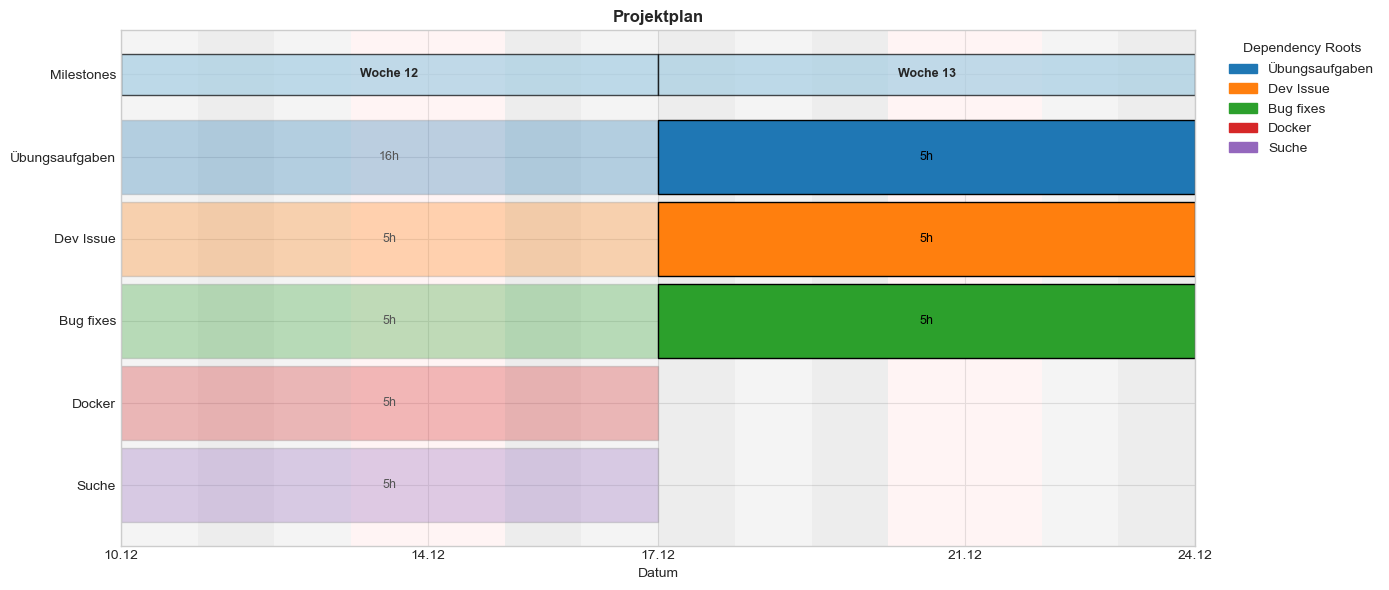

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from datetime import datetime, timedelta

# ==========================
# Beispiel-Daten mit Status
# ==========================
# status: "done" = erledigt (ausgrauen), "open" = noch offen
planned_issues = [
    
    ("Übungsaufgaben", 16, 8, [], "done"),
    ("Übungsaufgaben aktuell", 5, 8, ["Übungsaufgaben"], "open"),
    # Dev Issue in zwei Phasen
    ("Dev Issue", 5, 8, [], "done"),
    ("Dev Issue aktuell", 5, 8, ["Dev Issue"], "open"),
    # Bug fixes in zwei Phasen
    ("Bug fixes", 5, 8, [], "done"),
    ("Bug fixes aktuell", 5, 8, ["Bug fixes"], "open"),
    ("Docker", 5, 8, [], "done"),
    ("Suche", 5, 8, [], "done"),
]

df = pd.DataFrame(
    planned_issues,
    columns=["issue", "estimated_hours", "planned_days", "dependencies", "status"]
)

# ==========================
# Arbeitstage zählen (inkl. Starttag, Wochenenden erlaubt)
# ==========================
def add_workdays(start, days):
    current = start
    added = 1  # Starttag zählt
    while added < days:
        current += timedelta(days=1)
        added += 1
    return current

# ==========================
# Topologische Sortierung
# ==========================
remaining = set(df["issue"])
resolved = []
deps_map = df.set_index("issue")["dependencies"].to_dict()

while remaining:
    progress = False
    for issue in list(remaining):
        deps = deps_map[issue]
        if all(dep in resolved for dep in deps):
            resolved.append(issue)
            remaining.remove(issue)
            progress = True
    if not progress:
        raise RuntimeError("Zirkuläre oder ungültige Abhängigkeiten im Datensatz!")

# ==========================
# Start- und Enddaten berechnen
# ==========================
start_date = datetime(2025, 12, 10)
planned_starts = {}
planned_ends = {}

for issue in resolved:
    row = df.loc[df["issue"] == issue].iloc[0]

    if row["dependencies"]:
        dep_ends = [planned_ends[dep] for dep in row["dependencies"]]
        start = add_workdays(max(dep_ends), 1)  # Start = nächster Tag nach letzter Dependency
    else:
        start = start_date                      # Standard: Start mit Projektstart

    end = add_workdays(start, row["planned_days"])
    planned_starts[issue] = start
    planned_ends[issue] = end

df["planned_start"] = df["issue"].map(planned_starts)
df["planned_end"] = df["issue"].map(planned_ends)


# ==========================
# Root-Farblogik
# ==========================
def find_root(issue, df):
    deps = df.loc[df["issue"] == issue, "dependencies"].values[0]
    if not deps:
        return issue
    return find_root(deps[0], df)

df["root"] = df["issue"].apply(lambda i: find_root(i, df))

colors = list(mcolors.TABLEAU_COLORS.values())
roots = df["root"].unique()
root_colors = {root: colors[i % len(colors)] for i, root in enumerate(roots)}

# ==========================
# Sortieren für das Diagramm
# ==========================
df_sorted = df.sort_values("planned_start")

# Eine gemeinsame Zeile für Dev Issue & Dev Issue aktuell,
# sowie Bug fixes & Bug fixes aktuell
y_pos = {}
current_y = 0

for issue in df_sorted["issue"]:
    base_name = issue.replace(" aktuell", "")  # z.B. "Dev Issue aktuell" -> "Dev Issue"

    if base_name in ["Dev Issue", "Bug fixes", "Suche", "Übungsaufgaben", "Docker"]:
        if base_name not in y_pos:
            y_pos[base_name] = current_y
            current_y += 1
        y_pos[issue] = y_pos[base_name]
    else:
        if issue not in y_pos:
            y_pos[issue] = current_y
            current_y += 1

# ==========================
# Diagramm erstellen
# ==========================
fig, ax = plt.subplots(figsize=(14, 6))

# Hintergrund einfärben
curr_date = df_sorted["planned_start"].min()
end_date = datetime(2025, 12, 24)

while curr_date <= end_date:
    next_day = curr_date + timedelta(days=1)
    color = "#ffeaea" if curr_date.weekday() >= 5 else (
        "#eaeaea" if curr_date.day % 2 == 0 else "#dcdcdc"
    )
    ax.axvspan(
        mdates.date2num(curr_date),
        mdates.date2num(next_day),
        facecolor=color,
        alpha=0.5,
    )
    curr_date = next_day

# ==========================
# Tasks zeichnen (Enddatum inklusiv)
# ==========================
completed_alpha = 0.3   # Transparenz für erledigte Tasks
completed_edge = "#888" # Randfarbe für erledigte Tasks

for _, r in df_sorted.iterrows():
    start_num = mdates.date2num(r["planned_start"])
    end_num = mdates.date2num(r["planned_end"])
    width = end_num - start_num
    y = y_pos[r["issue"]]

    base_color = root_colors[r["root"]]

    if r["status"] == "done":
        facecolor = base_color
        alpha = completed_alpha
        edgecolor = completed_edge
        text_color = "#555"
    else:
        facecolor = base_color
        alpha = 1.0
        edgecolor = "black"
        text_color = "black"

    ax.barh(
        y,
        width,
        left=start_num,
        height=0.9,
        color=facecolor,
        edgecolor=edgecolor,
        alpha=alpha,
    )

    ax.text(
        start_num + width / 2,
        y,
        f"{r['estimated_hours']}h",
        va="center",
        ha="center",
        fontsize=9,
        color=text_color,
    )

# ==========================
# Meilensteine
# ==========================
milestone_start = datetime(2025, 12, 10)
diagram_end_date = datetime(2025, 12, 24)

milestones = []
current = milestone_start
ms_number = 12

while current < diagram_end_date:
    next_wed = current + timedelta(days=7)
    if next_wed > diagram_end_date:
        next_wed = diagram_end_date
    milestones.append((current, next_wed, f"Woche {ms_number}"))
    current = next_wed
    ms_number += 1

ms_y = -1
for start, end, label in milestones:
    start_num = mdates.date2num(start)
    end_num = mdates.date2num(end)

    ax.barh(
        ms_y,
        end_num - start_num,
        left=start_num,
        height=0.5,
        color="#a6cee3",
        edgecolor="black",
        alpha=0.7,
    )
    ax.text(
        start_num + (end_num - start_num) / 2,
        ms_y,
        label,
        va="center",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# ==========================
# Achsen: Labels auf Basis-Namen
# ==========================
unique_labels = []
label_positions = []

for issue, ypos in y_pos.items():
    base_name = issue.replace(" aktuell", "")
    if base_name not in unique_labels:
        unique_labels.append(base_name)
        label_positions.append(ypos)

ax.set_yticks(label_positions + [ms_y])
ax.set_yticklabels(unique_labels + ["Milestones"])
ax.invert_yaxis()

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=(2, 6)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))

ax.set_xlabel("Datum")
ax.set_title("Projektplan", fontsize=12, weight="bold")

ax.set_xlim(
    mdates.date2num(datetime(2025, 12, 10)),
    mdates.date2num(datetime(2025, 12, 24)),
)

# Legende
patches = [plt.Rectangle((0, 0), 1, 1, color=root_colors[r]) for r in roots]
ax.legend(
    patches,
    roots,
    title="Dependency Roots",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

plt.tight_layout()
plt.show()
